# Olist E-commerce project

In [28]:
# import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [29]:
# importing data
customers_data = pd.read_csv("C:/Users/Brayn/Desktop/Github/Olist dataset/olist_customers_dataset.csv")
geo_location = pd.read_csv("C:/Users/Brayn/Desktop/Github/Olist dataset/olist_geolocation_dataset.csv")
orders = pd.read_csv("C:/Users/Brayn/Desktop/Github/Olist dataset/olist_orders_dataset.csv")
order_items = pd.read_csv("C:/Users/Brayn/Desktop/Github/Olist dataset/olist_order_items_dataset.csv")
order_payments = pd.read_csv("C:/Users/Brayn/Desktop/Github/Olist dataset/olist_order_payments_dataset.csv")
products = pd.read_csv("C:/Users/Brayn/Desktop/Github/Olist dataset/olist_products_dataset.csv")
sellers = pd.read_csv("C:/Users/Brayn/Desktop/Github/Olist dataset/olist_sellers_dataset.csv")
order_reviews = pd.read_csv("C:/Users/Brayn/Desktop/Github/Olist dataset/olist_order_reviews_dataset.csv")

In [30]:
# merging the data
data = orders.merge(customers_data, on='customer_id', how='left')

data = data.merge(order_items, on='order_id', how='left')

data = data.merge(products, on='product_id', how='left')

data = data.merge(sellers, on='seller_id', how='left')

data = data.merge(order_payments, on='order_id', how='left')

data = data.merge(order_reviews, on='order_id', how='left')

In [31]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


# Data cleaning

In [32]:
# information about the data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  str    
 1   customer_id                    119143 non-null  str    
 2   order_status                   119143 non-null  str    
 3   order_purchase_timestamp       119143 non-null  str    
 4   order_approved_at              118966 non-null  str    
 5   order_delivered_carrier_date   117057 non-null  str    
 6   order_delivered_customer_date  115722 non-null  str    
 7   order_estimated_delivery_date  119143 non-null  str    
 8   customer_unique_id             119143 non-null  str    
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  str    
 11  customer_state                 119143 non-null  str    
 12  order_item_id                  118310 non

In [33]:
# checking for duplicates
data.duplicated().sum()

np.int64(0)

In [34]:
# checking for missing data
data.isna().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853


In [35]:
data.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

In [36]:
# columns with nas to drop
na_col = ['order_item_id', 'product_id', 'seller_id', 'price', 'freight_value', 'review_id', 
          'review_score', 'review_creation_date', 'review_answer_timestamp', 'price', 'freight_value', 'payment_value']
data = data.dropna(subset=na_col)

# columns to drop, not useful, mostly metadata columns
meta_columns = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty',
                'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
data = data.drop(columns=meta_columns)
data = data.drop(columns=['review_comment_title', 'review_comment_message'])

# filling missing data
data['product_category_name'] = data['product_category_name'].fillna('unknown')

In [37]:
data.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1235
order_delivered_customer_date    2471
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
review_id   

In [38]:
# filling missing data
data['product_category_name'] = data['product_category_name'].fillna('unknown')
data['payment_type'] = data['payment_type'].fillna(data['payment_type'].mode()[0])
data['payment_sequential'] = data['payment_sequential'].fillna(data['payment_sequential'].median())
data['payment_installments'] = data['payment_installments'].fillna(data['payment_installments'].median())

In [39]:
# checking the info again
data.info()

<class 'pandas.DataFrame'>
Index: 117329 entries, 0 to 119142
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117329 non-null  str    
 1   customer_id                    117329 non-null  str    
 2   order_status                   117329 non-null  str    
 3   order_purchase_timestamp       117329 non-null  str    
 4   order_approved_at              117314 non-null  str    
 5   order_delivered_carrier_date   116094 non-null  str    
 6   order_delivered_customer_date  114858 non-null  str    
 7   order_estimated_delivery_date  117329 non-null  str    
 8   customer_unique_id             117329 non-null  str    
 9   customer_zip_code_prefix       117329 non-null  int64  
 10  customer_city                  117329 non-null  str    
 11  customer_state                 117329 non-null  str    
 12  order_item_id                  117329 non-null

so we're only left with customer order date and delivery date, didn't fill it because I didn't want to provide the wrong infomation as this is a reflection of a customers true order information, so when it comes to date features, we need to tred lightly.

# Exploratory Data Analysis (EDA)

In [40]:
# summary statistics 
pd.set_option('display.float_format', '{:.2f}'.format)
data.drop(columns=['customer_zip_code_prefix', 'order_item_id', 'seller_zip_code_prefix']).describe()

,price,freight_value,payment_sequential,payment_installments,payment_value,review_score
count,117329.00,117329.00,117329.00,117329.00,117329.00,117329.00
mean,120.52,20.03,1.09,2.94,172.06,4.03
std,182.94,15.83,0.73,2.78,265.39,1.39
min,0.85,0.00,1.00,0.00,0.00,1.00
25%,39.90,13.08,1.00,1.00,60.75,4.00
50%,74.90,16.28,1.00,2.00,108.10,5.00
75%,134.90,21.18,1.00,4.00,189.06,5.00
max,6735.00,409.68,29.00,24.00,13664.08,5.00


- The average price of the items is 120.52
- Price column seems to have some outliers with the minimum value being 0.85 and the max value being 6735.00
- The average value for the goods being transported in 20.02 and similar to price, the freight value also does seem to have outliers.
- The customers normally average making one trasaction payment, with 3 installments for goods around an average value of 172.06
- Most of the customers seeem to be satisfied with the service, since they average a review score rating of 4.

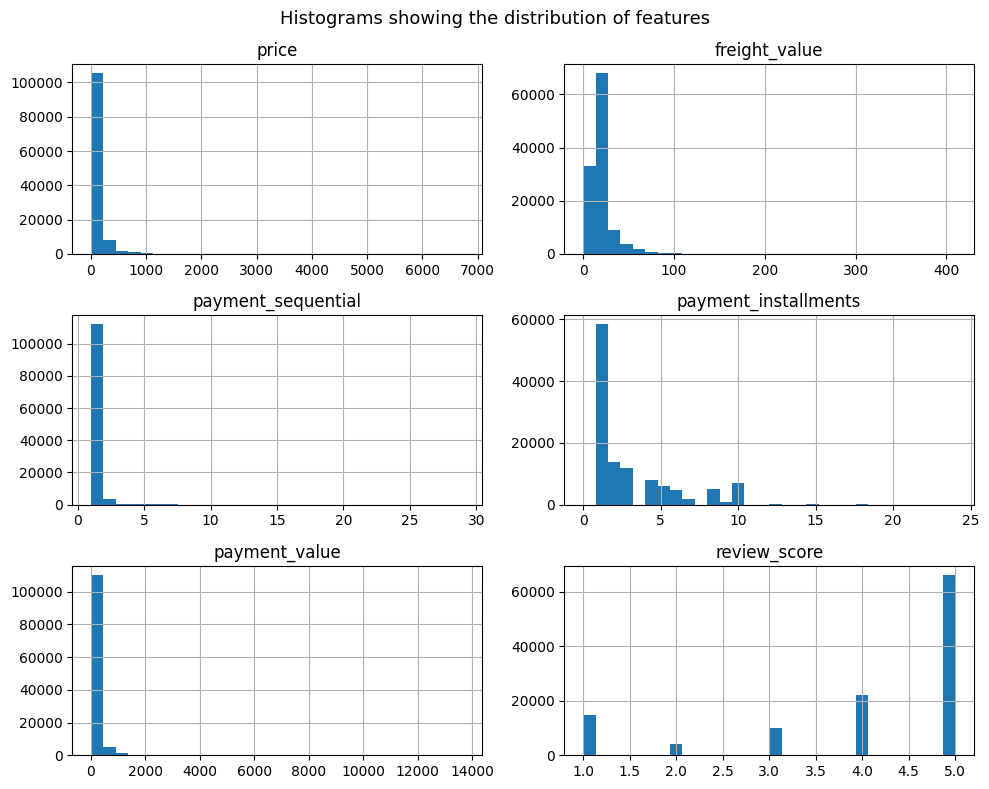

In [41]:
# Distribution of the features
data.drop(columns=['customer_zip_code_prefix', 'order_item_id', 'seller_zip_code_prefix']).hist(bins=30, figsize=(10, 8))
plt.suptitle('Histograms showing the distribution of features', size=13)
plt.tight_layout()
plt.show()

- majority of the features seem to have a positively skewed distribution with the 'review_score' having a negatively skewed distribution.
- The review score contians a majority of the 5.0 ratings, with ratings 1.0, 3.0 and 4.0 ranging between (10000 and 22000). Less than 5000 customers gave a rating of 2.0

# RFM analysis

In [42]:
# converting to datetime and aggregating the data
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'])

data_agg = data[data['order_status'] == 'delivered']
data_agg.info()

<class 'pandas.DataFrame'>
Index: 114859 entries, 0 to 119142
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       114859 non-null  str           
 1   customer_id                    114859 non-null  str           
 2   order_status                   114859 non-null  str           
 3   order_purchase_timestamp       114859 non-null  datetime64[us]
 4   order_approved_at              114844 non-null  str           
 5   order_delivered_carrier_date   114857 non-null  str           
 6   order_delivered_customer_date  114851 non-null  str           
 7   order_estimated_delivery_date  114859 non-null  str           
 8   customer_unique_id             114859 non-null  str           
 9   customer_zip_code_prefix       114859 non-null  int64         
 10  customer_city                  114859 non-null  str           
 11  customer_state  

In [43]:
# aggregating orders
orders = data_agg.groupby(['customer_unique_id', 'order_id']).agg(
    order_date=('order_purchase_timestamp', 'max'),
    order_value=('payment_value', 'max'),
    review_score=('review_score', 'mean')
).reset_index()
orders.head()

,customer_unique_id,order_id,order_date,order_value,review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05-10 10:56:27,141.90,5.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05-07 11:11:27,27.19,4.00
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03-10 21:05:03,86.22,3.00
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10-12 20:29:41,43.62,4.00
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11-14 19:45:42,196.89,5.00


In [44]:
data_agg.info()

<class 'pandas.DataFrame'>
Index: 114859 entries, 0 to 119142
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       114859 non-null  str           
 1   customer_id                    114859 non-null  str           
 2   order_status                   114859 non-null  str           
 3   order_purchase_timestamp       114859 non-null  datetime64[us]
 4   order_approved_at              114844 non-null  str           
 5   order_delivered_carrier_date   114857 non-null  str           
 6   order_delivered_customer_date  114851 non-null  str           
 7   order_estimated_delivery_date  114859 non-null  str           
 8   customer_unique_id             114859 non-null  str           
 9   customer_zip_code_prefix       114859 non-null  int64         
 10  customer_city                  114859 non-null  str           
 11  customer_state  

In [45]:
# getting max date
date_capture = data_agg['order_purchase_timestamp'].max()

# creating an rfm dataframe
pre_rfm = orders.groupby('customer_unique_id').agg(
    recency=('order_date', lambda x: (date_capture - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('order_value', 'sum'),
    satisfaction=('review_score', 'mean')
).reset_index()

pre_rfm.head()

,customer_unique_id,recency,frequency,monetary,satisfaction
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,5.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,4.00
2,0000f46a3911fa3c0805444483337064,536,1,86.22,3.00
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,4.00
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,5.00


In [46]:
# dropping customer_unique_id
rfm = pre_rfm.drop(columns=['customer_unique_id'])

# scorng each dimensions into quartiles
rfm['r_score'] = pd.qcut(rfm['recency'], q=4, labels=[4,3,2,1]) 
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['s_score'] = pd.qcut(rfm['satisfaction'].rank(method='first'), q=4, labels=[1,2,3,4])

rfm[['r_score', 'f_score', 'm_score', 's_score']] = rfm[['r_score', 'f_score', 'm_score', 's_score']].astype(int)

# compose all 
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score'] + rfm['s_score']

# summary statistics
rfm[['r_score', 'f_score', 'm_score', 's_score', 'rfm_score']].describe()

,r_score,f_score,m_score,s_score,rfm_score
count,92754.00,92754.00,92754.00,92754.00,92754.00
mean,2.50,2.50,2.50,2.50,10.00
std,1.12,1.12,1.12,1.12,2.44
min,1.00,1.00,1.00,1.00,4.00
25%,2.00,1.25,1.25,1.25,8.00
50%,3.00,2.50,2.50,2.50,10.00
75%,4.00,3.75,3.75,3.75,12.00
max,4.00,4.00,4.00,4.00,16.00


In [47]:
rfm['f_score'].value_counts()

f_score
1    23189
4    23189
2    23188
3    23188
Name: count, dtype: int64

In [48]:
# assigning relevant segments
def customer_segment(row):
    r, f, m, s = row['r_score'], row['f_score'], row['m_score'], row['s_score']
    if r >= 4 and f >= 4 and m >= 4 and s >= 3:
        return 'CHAMPIONS'
    elif r >= 3 and f >= 3 and s >= 3:
        return 'LOYAL'
    elif r >= 4 and f <= 2:
        return 'NEW / LIGHT'
    elif r <= 2 and f >= 4 and s >= 3:
        return 'AT RISK'
    elif r <= 2 and m >= 4:
        return 'HIGH VALUE AT RISK'
    elif r <= 2 and f <= 2 and s <= 2:
        return 'LOST'
    elif s <= 1:
        return 'DISSATISFIED'
    else:
        return 'MID-TIER'

rfm['Segment'] = rfm.apply(customer_segment, axis=1)

# checking value counts
rfm['Segment'].value_counts()

Segment
MID-TIER              28873
DISSATISFIED          12512
LOYAL                 12507
NEW / LIGHT           11631
LOST                  10118
HIGH VALUE AT RISK     9666
AT RISK                6411
CHAMPIONS              1036
Name: count, dtype: int64

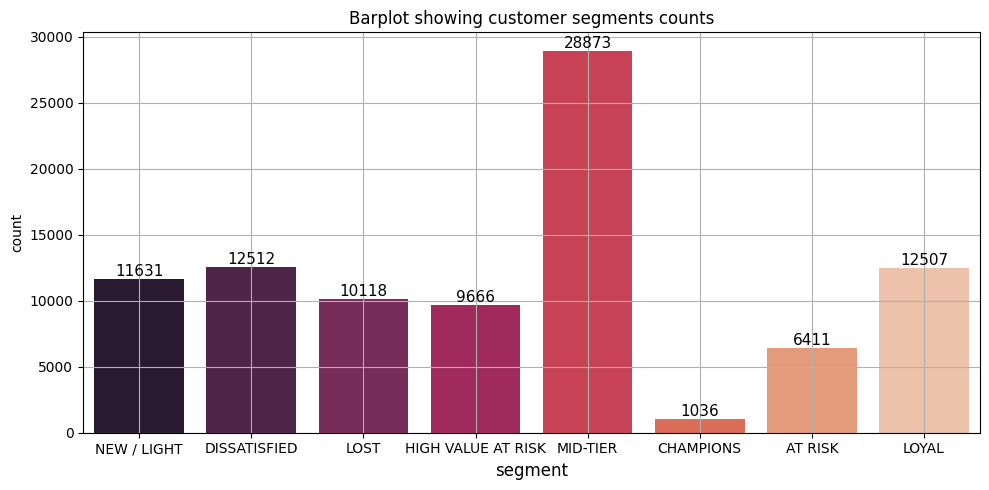

In [49]:
# visualize
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.countplot(rfm, x='Segment', palette='rocket', ax=ax)
for container in ax.containers:
    ax.bar_label(container, color='black', size=11)
    ax.set_title('Barplot showing customer segments counts')
    ax.set_xlabel('segment', size=12)
    ax.grid(True)
plt.tight_layout()
plt.show()

- The barplot seems to be very realistic, with champions have the minority of the customers.
- Majority of the customers are mid-tier customers, everything about the customer is reasonable, they spend reasonably, they make decent amounts of purchases, they contribute reasonable amount of revenue, not too much and also not too little.
- A significant amont of our customers seem to be dissatisfied

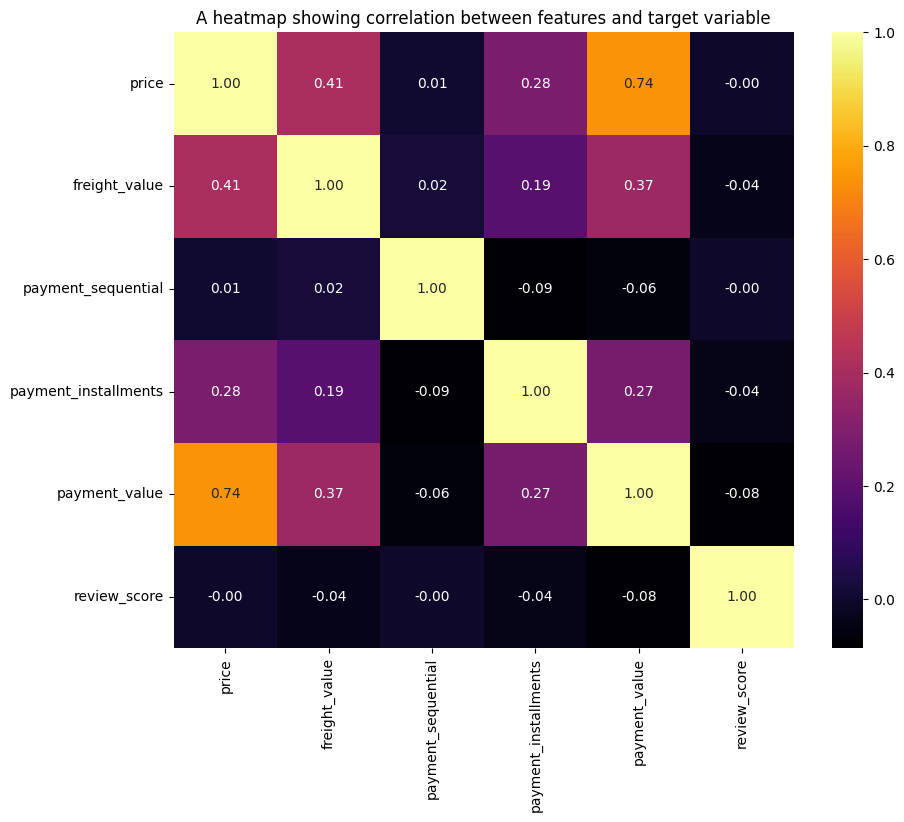

In [50]:
# heatmap
heat_columns = ['price', 'freight_value', 'payment_sequential', 'payment_installments', 'payment_value', 'review_score']

plt.figure(figsize=(10, 8))
plt.title('A heatmap showing correlation between features and target variable')
sns.heatmap(data[heat_columns].corr(), annot=True, cmap='inferno', fmt='.2f')
plt.tight_layout
plt.show()

- the features have little to no correlation with the target variable ('review_score')
- 'price_value' has a high correlation with 'price'
- 'price' and 'freight_value' have a moderate relationship
- Most of the features have a low positive/negative correlation with other feature

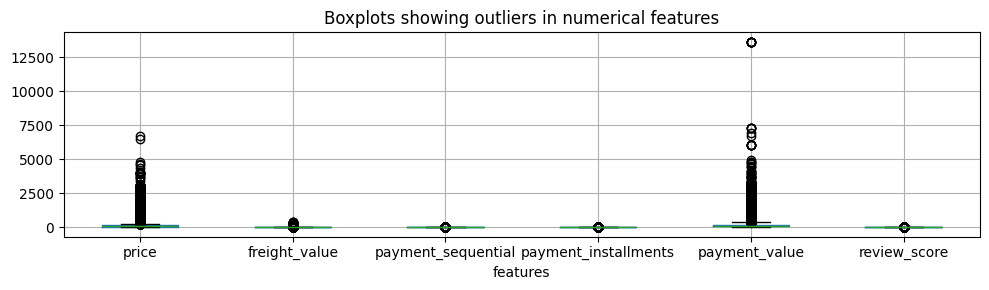

In [51]:
# checking for outliers.boxplot()
data.drop(columns=['customer_zip_code_prefix', 'order_item_id', 'seller_zip_code_prefix']).boxplot(figsize=(10, 3))
plt.title('Boxplots showing outliers in numerical features')
plt.xlabel('features')
plt.tight_layout()
plt.show()

Price and payment value have so many outliers compared to the other features.

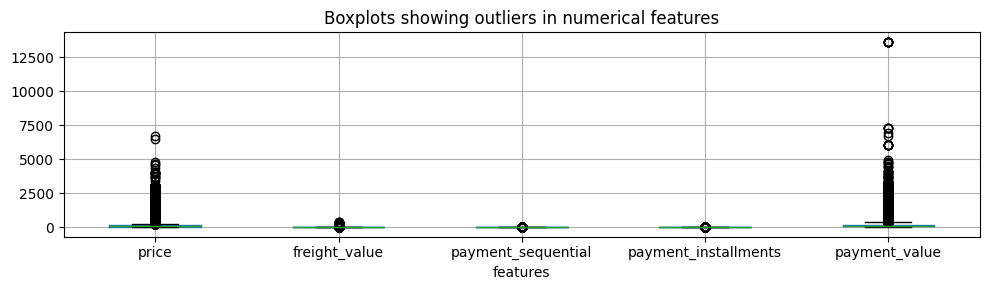

In [52]:
# handling outliers by first doing log transformations since most of the numerical features are positively skewed
import copy
data1 = data.copy()

log_columns = ['price', 'freight_value', 'payment_sequential', 'payment_installments', 'payment_value']
for col in log_columns:
    data1[col] = np.log1p(data1[col])

# checking for outliers
data[log_columns].boxplot(figsize=(10, 3))
plt.title('Boxplots showing outliers in numerical features')
plt.xlabel('features')
plt.tight_layout()
plt.show()

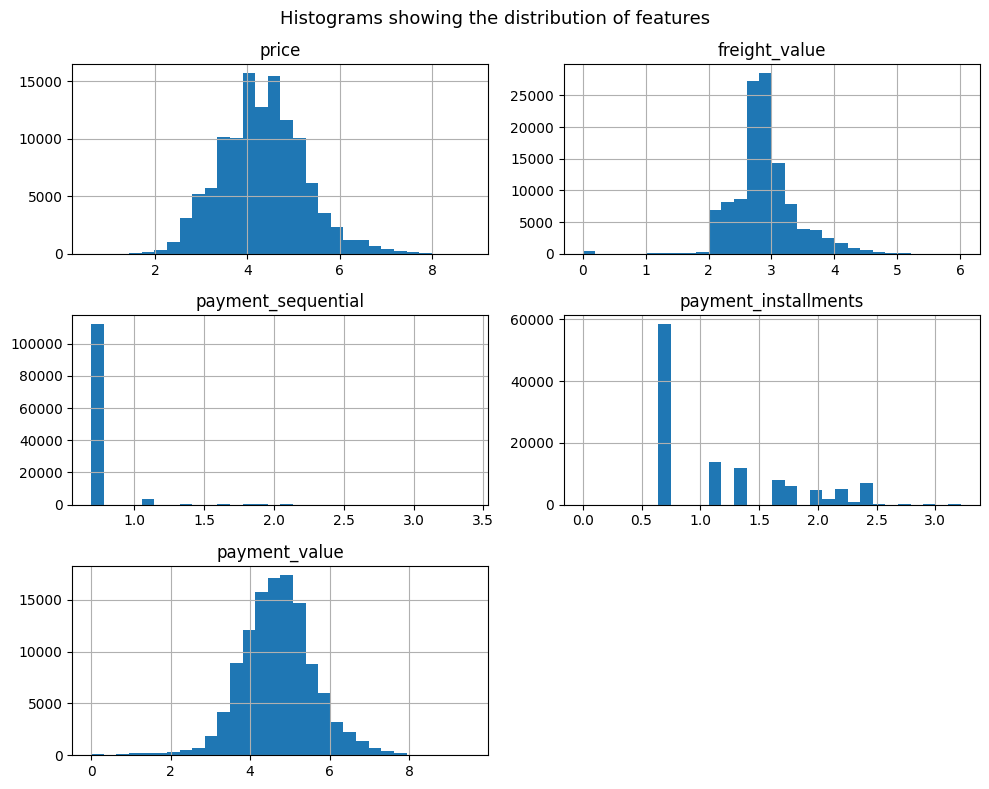

In [53]:
data1[log_columns].hist(bins=30, figsize=(10, 8))
plt.suptitle('Histograms showing the distribution of features', size=13)
plt.tight_layout()
plt.show()

- using log transformating helped in trying to normalize the distribution of the numerical features
- deciding to keep the outliers as well since I suspect they migh carry imortant information

# FEATURE ENGINEERING

In [54]:
# defining categorical columns
categorical_columns = [col for col in data1.columns if data[col].dtype=='str']

numerical_columns = [col for col in data1.columns if data[col].dtype in ['float64', 'int64']]

print(f'categorical_columns: {categorical_columns}\n')
print(f'numerical_columns: {numerical_columns}\n')

categorical_columns: ['order_id', 'customer_id', 'order_status', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_city', 'customer_state', 'product_id', 'seller_id', 'shipping_limit_date', 'product_category_name', 'seller_city', 'seller_state', 'payment_type', 'review_id', 'review_creation_date', 'review_answer_timestamp']

numerical_columns: ['customer_zip_code_prefix', 'order_item_id', 'price', 'freight_value', 'seller_zip_code_prefix', 'payment_sequential', 'payment_installments', 'payment_value', 'review_score']



In [55]:
# creating a dataframe for model (aggregation)
extra_features = data.groupby('customer_unique_id').agg(
    unique_categories=('product_category_name', 'nunique'),
    preferred_payment=('payment_type', lambda x: x.mode()[0]),
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean'),
    avg_installments=('payment_installments', 'mean'),
    avg_payment_sequential=('payment_sequential', 'mean')
).reset_index()

# creating new dataframe, merging rfm features with selected features from OG dataframe for modeling
model_data = pre_rfm.merge(extra_features, on='customer_unique_id', how='left')
model_data1 = model_data.drop(columns=['customer_unique_id'])
model_data1.head()

,recency,frequency,monetary,satisfaction,unique_categories,preferred_payment,avg_price,avg_freight,avg_installments,avg_payment_sequential
0,111,1,141.90,5.00,1,credit_card,129.90,12.00,8.00,1.00
1,114,1,27.19,4.00,1,credit_card,18.90,8.29,1.00,1.00
2,536,1,86.22,3.00,1,credit_card,69.00,17.22,8.00,1.00
3,320,1,43.62,4.00,1,credit_card,25.99,17.63,4.00,1.00
4,287,1,196.89,5.00,1,credit_card,180.00,16.89,6.00,1.00


In [56]:
model_data1.info()

<class 'pandas.DataFrame'>
RangeIndex: 92754 entries, 0 to 92753
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   recency                 92754 non-null  int64  
 1   frequency               92754 non-null  int64  
 2   monetary                92754 non-null  float64
 3   satisfaction            92754 non-null  float64
 4   unique_categories       92754 non-null  int64  
 5   preferred_payment       92754 non-null  str    
 6   avg_price               92754 non-null  float64
 7   avg_freight             92754 non-null  float64
 8   avg_installments        92754 non-null  float64
 9   avg_payment_sequential  92754 non-null  float64
dtypes: float64(6), int64(3), str(1)
memory usage: 8.0 MB


In [57]:
# defining columns to use for modeling
cat_columns = [col for col in model_data1.columns if model_data[col].dtype=='str']

num_columns = [col for col in model_data1.columns if model_data[col].dtype in ['float64', 'int64']]

print(f'cat_columns: {cat_columns}\n')
print(f'num_columns: {num_columns}')

cat_columns: ['preferred_payment']

num_columns: ['recency', 'frequency', 'monetary', 'satisfaction', 'unique_categories', 'avg_price', 'avg_freight', 'avg_installments', 'avg_payment_sequential']


In [58]:
# concatinating all the necessary columns
all_columns = num_columns + cat_columns

# preprocessing

In [59]:
# import modules
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# defining the preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_columns),
    ('num', RobustScaler(), num_columns)
])

# prerocessing the data
model_data_scaled = preprocessor.fit_transform(model_data1)

# getting categorical names
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_columns)

# creating a concat list
all_columns = num_columns + list(cat_names)

# converting back to dataframe
data1_scaled = pd.DataFrame(model_data_scaled, columns=all_columns)
data1_scaled.head()

,recency,frequency,monetary,satisfaction,unique_categories,avg_price,avg_freight,avg_installments,avg_payment_sequential,preferred_payment_credit_card,preferred_payment_debit_card,preferred_payment_voucher
0,1.00,0.00,0.00,-0.46,0.00,0.30,0.00,0.00,0.52,-0.56,2.00,0.00
1,1.00,0.00,0.00,-0.45,0.00,-0.67,-1.00,0.00,-0.62,-1.04,-0.33,0.00
2,1.00,0.00,0.00,1.37,0.00,-0.17,-2.00,0.00,-0.10,0.11,2.00,0.00
3,1.00,0.00,0.00,0.44,0.00,-0.53,-1.00,0.00,-0.55,0.16,0.67,0.00
4,1.00,0.00,0.00,0.30,0.00,0.76,0.00,0.00,1.04,0.06,1.33,0.00


# Customer segmentation with ML models

# 1. KMeans clustering

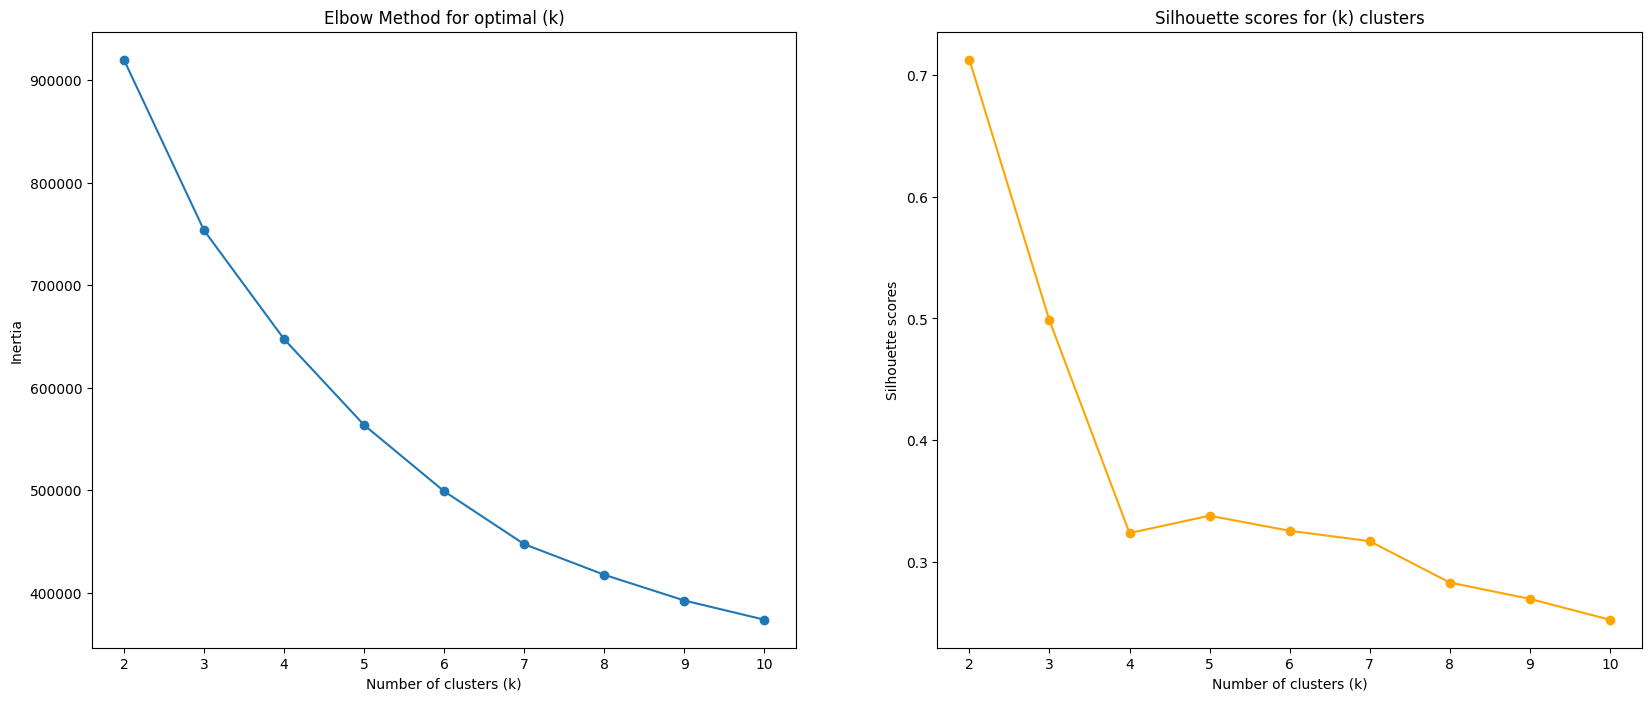

In [60]:
# importing the modules
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []

k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(data1_scaled)
    inertias.append(kmeans.inertia_)

    sil_score = silhouette_score(data1_scaled, cluster_labels)
    silhouette_scores.append(sil_score)

#plotting
plt.subplots(1, 2, figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for optimal (k)')

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette scores')
plt.title('Silhouette scores for (k) clusters')
plt.show()

The number of clusters I'm going with is k=3 because the elbow is around 3-4 clusters and the silhoute score at k=3 is at its highest.

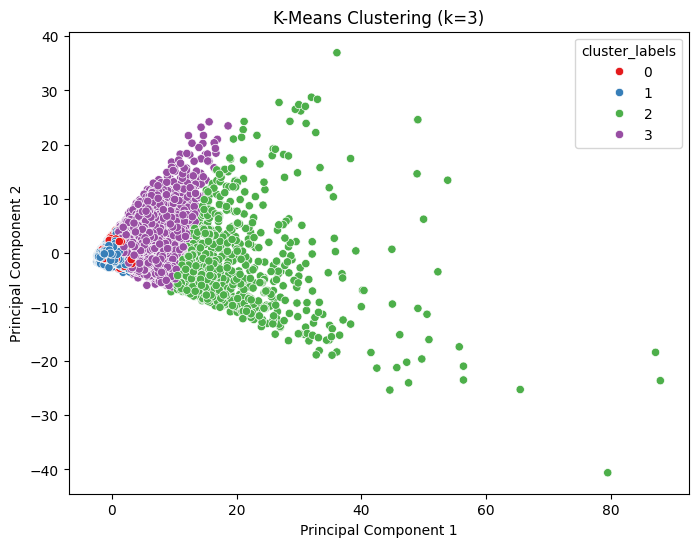

In [63]:
#Dimensionality Reduction with PCA
from sklearn.decomposition import PCA

# defining cluster_labels and pca
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(data1_scaled)
cluster_labels

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data1_scaled)

# Create a new DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

#adding cluster labels to the pca_df
pca_df['cluster_labels'] = cluster_labels

# Visualize the clustered data (colored by predicted cluster assignments)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, hue='cluster_labels', palette='Set1') # Color by cluster
plt.title('K-Means Clustering (k=3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [64]:
print(pd.Series(cluster_labels).value_counts().sort_index())

0    17482
1    64556
2     1044
3     9672
Name: count, dtype: int64


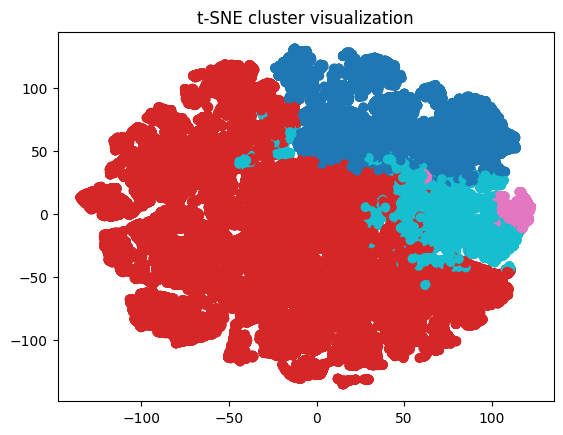

In [65]:
# importing tsne
from sklearn.manifold import TSNE
# defining
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(data1_scaled)

# plotting
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=cluster_labels, cmap='tab10')
plt.title('t-SNE cluster visualization')
plt.show()

# 2. DBScan

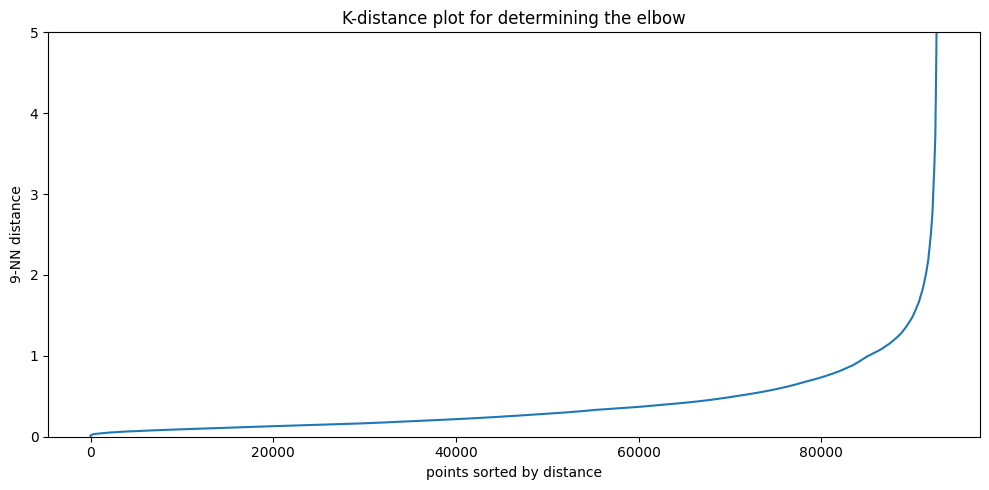

In [66]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import davies_bouldin_score

# K-distance plot to find esp
features = data1_scaled.columns

min_samples = 10
k = min_samples - 1

nbrs = NearestNeighbors(n_neighbors=k).fit(data1_scaled)

distances,_ = nbrs.kneighbors(data1_scaled)
k_distances = np.sort(distances[:, -1])

# plotting
plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title('K-distance plot for determining the elbow')
plt.xlabel('points sorted by distance')
plt.ylabel(f'{k}-NN distance')
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

- eps sits at about 1.1 - 1.3, so I decided to go with eps=1.25

clusters found: 6
noise points: 2913
Silhouette score: 0.5989 (higher ---- better , max 1)
Davies_bouldin score: 0.6137 (lower ---- better , min 1)


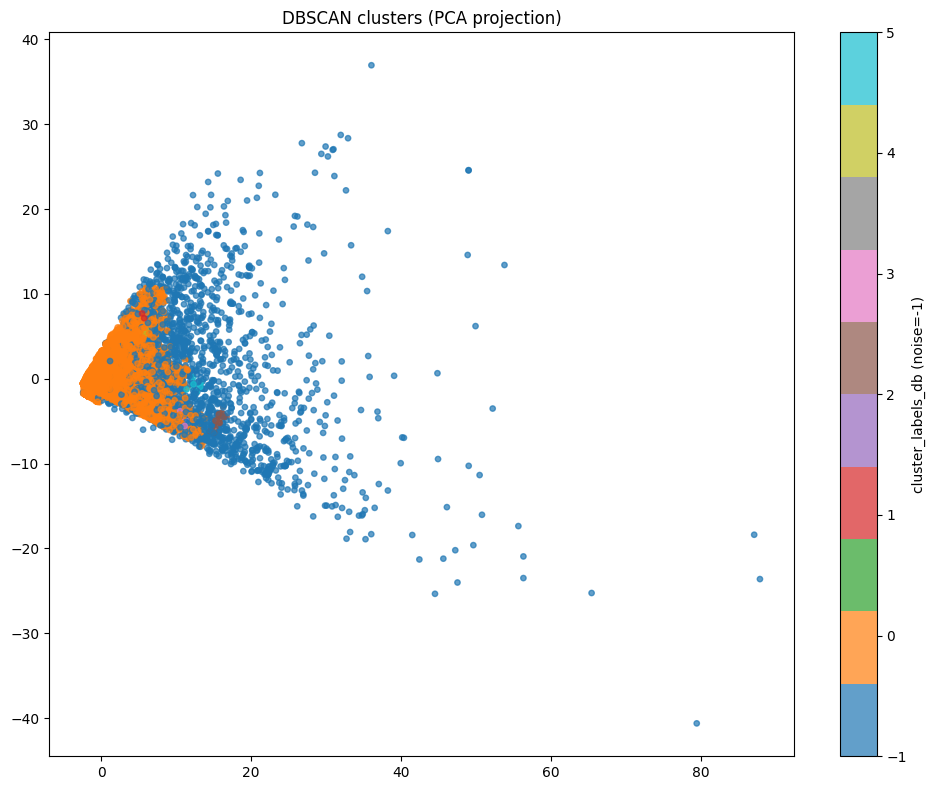

In [68]:
# fitting the DBSCAN for chosen eps
eps_val = 1.25
db = DBSCAN(eps=eps_val, min_samples=min_samples, metric='euclidean')
cluster_labels_db = db.fit_predict(data1_scaled)

# checking cluster distribution
n_clusters = len(set(cluster_labels_db)) - (1 if -1 in cluster_labels_db else 0)
n_noise = (cluster_labels_db == -1).sum()
print(f'clusters found: {n_clusters}')
print(f'noise points: {n_noise}')

# evaluation using sil scores
mask = cluster_labels_db != -1
if len(set(cluster_labels_db[mask])) > 1:
    sil = silhouette_score(data1_scaled[mask], cluster_labels_db[mask])
    dbi = davies_bouldin_score(data1_scaled[mask], cluster_labels_db[mask])
    print(f'Silhouette score: {sil:.4f} (higher ---- better , max 1)')
    print(f'Davies_bouldin score: {dbi:.4f} (lower ---- better , min 1)')

# Principal component Analysis (PCA) visuals
pca = PCA(n_components=2)
pca_2 = pca.fit_transform(data1_scaled)

# plotting
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_2[:, 0], pca_2[:, 1], c=cluster_labels_db, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, label='cluster_labels_db (noise=-1)')
plt.title('DBSCAN clusters (PCA projection)')
plt.tight_layout()
plt.show()

- the clusters don't seem to be well separated, shows 6 clusters but visually we can only see 3-4 clusters..

In [69]:
print(pd.Series(cluster_labels_db).value_counts().sort_index())

-1     2913
 0    89778
 1       11
 2       26
 3       11
 4        6
 5        9
Name: count, dtype: int64


The reason why that was, is because we have one huge cluster that hosts the majority of the data points, which isnt right and also, (-1) cluster indicates that there are 2913 outliers. DBScan will then used for outlier removal instead of modeling.

# 3. Kmean clustering (final)

In [70]:
# Using DBSCAN just for outlier removal (mask), defined ealier
X_clean = data1_scaled[mask]

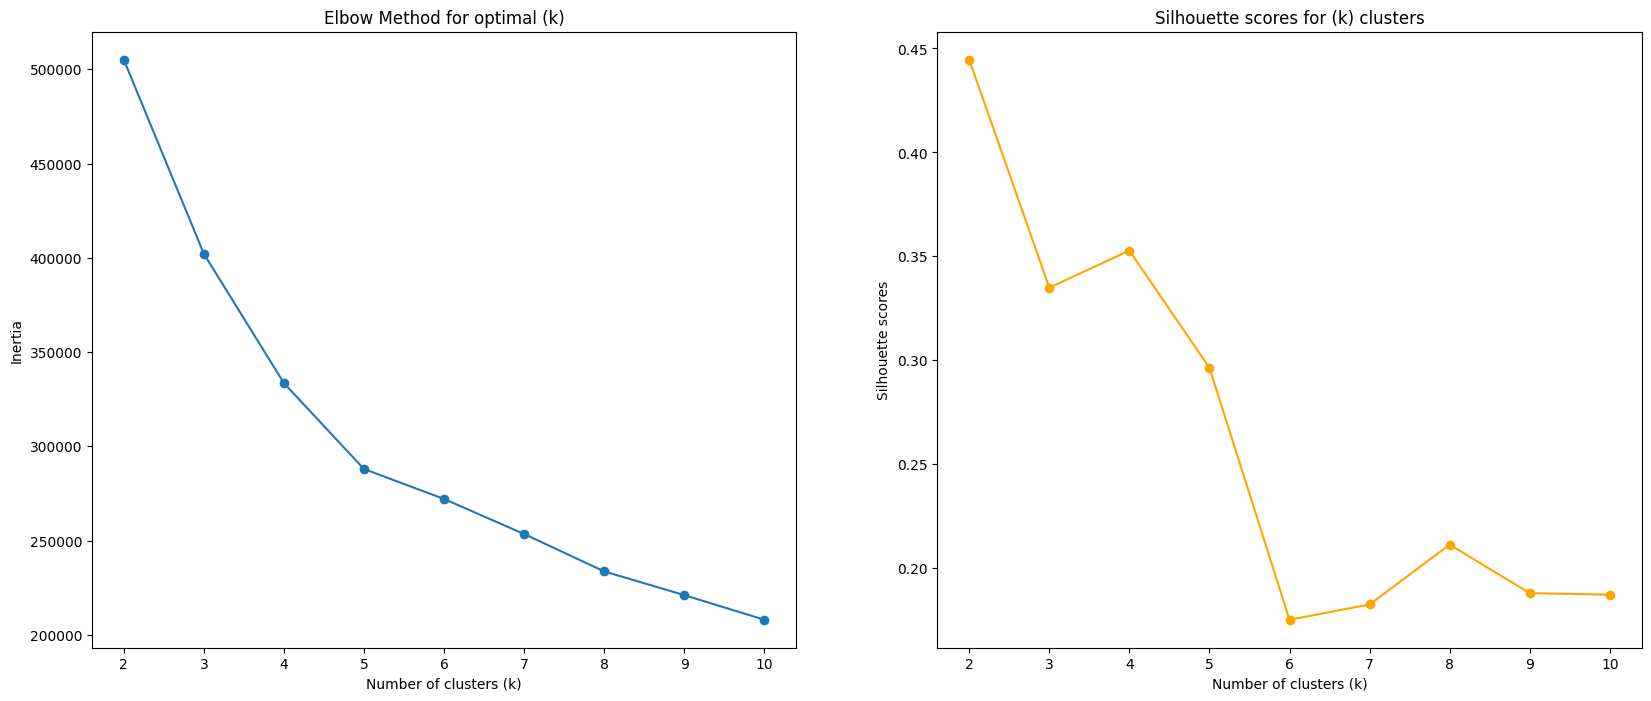

In [71]:
inertias = []
silhouette_scores = []

k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_clean)
    inertias.append(kmeans.inertia_)

    sil_score = silhouette_score(X_clean, cluster_labels)
    silhouette_scores.append(sil_score)

#plotting
plt.subplots(1, 2, figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for optimal (k)')

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette scores')
plt.title('Silhouette scores for (k) clusters')
plt.show()

- Its best to go with 4 clusters because its optimal for business sense segments and silhouette score on it is not bad itself

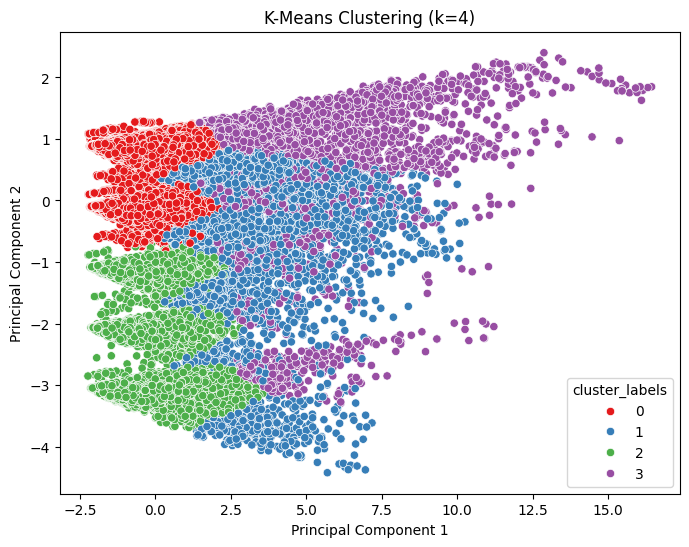

In [73]:
# Then fitting back into K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(X_clean)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_clean)

# Create a new DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

#adding cluster labels to the pca_df
pca_df['cluster_labels'] = cluster_labels

# Visualize the clustered data (colored by predicted cluster assignments)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=pca_df, hue='cluster_labels', palette='Set1') # Color by cluster
plt.title('K-Means Clustering (k=4)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

There is some separation to the data points but most of them are over-lapping.

In [74]:
# determining the counts per cluster
print(pd.Series(cluster_labels).value_counts().sort_index())

0    61390
1     7004
2    16682
3     4765
Name: count, dtype: int64


In [75]:
model_data.shape

(92754, 11)

In [76]:
# initialize all as -1 (noise/outlier)
model_data['cluster'] = cluster_labels_db

# assign cluster labels only to non-outlier rows
model_data.loc[mask, 'cluster'] = cluster_labels
model_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 92754 entries, 0 to 92753
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_unique_id      92754 non-null  str    
 1   recency                 92754 non-null  int64  
 2   frequency               92754 non-null  int64  
 3   monetary                92754 non-null  float64
 4   satisfaction            92754 non-null  float64
 5   unique_categories       92754 non-null  int64  
 6   preferred_payment       92754 non-null  str    
 7   avg_price               92754 non-null  float64
 8   avg_freight             92754 non-null  float64
 9   avg_installments        92754 non-null  float64
 10  avg_payment_sequential  92754 non-null  float64
 11  cluster                 92754 non-null  int64  
dtypes: float64(6), int64(4), str(2)
memory usage: 12.2 MB


In [77]:
model_data.head()

,customer_unique_id,recency,frequency,monetary,satisfaction,unique_categories,preferred_payment,avg_price,avg_freight,avg_installments,avg_payment_sequential,cluster
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,5.00,1,credit_card,129.90,12.00,8.00,1.00,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,4.00,1,credit_card,18.90,8.29,1.00,1.00,0
2,0000f46a3911fa3c0805444483337064,536,1,86.22,3.00,1,credit_card,69.00,17.22,8.00,1.00,2
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,4.00,1,credit_card,25.99,17.63,4.00,1.00,0
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,5.00,1,credit_card,180.00,16.89,6.00,1.00,0


In [78]:
# profiling the clusters
cluster_profiles = model_data.groupby('cluster').mean(numeric_only=True)
cluster_profiles

,recency,frequency,monetary,satisfaction,unique_categories,avg_price,avg_freight,avg_installments,avg_payment_sequential
cluster,,,,,,,,,
-1,237.23,1.26,914.91,3.57,1.19,650.65,60.55,5.39,1.14
0,238.10,1.03,106.79,4.75,1.02,81.44,15.76,2.50,1.02
1,206.60,1.01,214.80,4.31,1.01,159.35,47.50,3.74,1.01
2,241.69,1.02,119.70,1.93,1.03,83.97,16.86,2.73,1.02
3,246.88,1.02,509.37,4.40,1.01,470.44,23.87,5.87,1.01


- cluster (-1): Deemed outliers, they are considered our highest spenders, moderately satisfied.
- cluster (0): low value customers, with an average spending of 106.79 but highly satisfied. 
- cluster (1): Our regular customers, spending 214.80 on average, very satisfied as well.
- cluster (2): low value customers, low spenders, not satisfied with the products/service, we might be at risk of losing them.
- cluster (3): High value customers, spends a decently high amount, very satisfied, many installments.